# Maven Mega Mart: Transaction & Customer Analysis

## Project Overview

This project analyzes over **2 million retail transaction records** from Maven Mega Mart to understand purchasing behavior, sales performance, discount patterns, product performance, and customer spending trends.

The analysis combines transaction, product, and demographic data to identify meaningful patterns and generate business-oriented insights.

---

## Business Problem

The objective is to understand how customers and products contribute to overall sales and how factors such as discounts, time, household characteristics, and product categories influence purchasing behavior.

The analysis focuses on turning large-scale retail transaction data into actionable business insights.

---

## Key Questions

This analysis focuses on questions such as:

- What are the overall sales, quantity, and discount patterns?
- Which households contribute the most to total spending?
- Which products are the top performers?
- Are top-selling products discounted more heavily than average?
- How do sales and purchasing patterns change over time?
- What spending patterns can be observed across different demographic groups?
- How does household composition relate to customer spending?

---

## Analysis Approach

The project includes:

- Large-scale transaction data loading and memory optimization
- Data cleaning and preprocessing
- Feature engineering
- Sales and quantity analysis
- Household-level customer analysis
- Product performance analysis
- Discount analysis
- Time-series analysis of sales trends
- Year-over-year comparisons
- Day-of-week purchasing analysis
- Demographic spending analysis
- Business-oriented interpretation of results

---

## Tools & Technologies

- **Python**
- **Pandas**
- **NumPy**
- **Matplotlib**
- **Seaborn**
- **Exploratory Data Analysis**
- **Data Visualization**
- **Feature Engineering**

---

## Dataset

The project uses Maven Mega Mart retail transaction data containing over **2 million transaction records**, along with product and demographic information used for customer and product-level analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
transactions =  pd.read_csv('project_transactions.csv',
                           dtype={"DAY":"int16",
                                   "QUANTITY":"int32",
                                   "STORE_ID":"int32",
                                   "WEEK_NO":"int8"})
transactions.head()


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,1364,26984896261,1,842930,1,2.19,31742,0.00,1,0.0,0.0
1,1364,26984896261,1,897044,1,2.99,31742,-0.40,1,0.0,0.0
2,1364,26984896261,1,920955,1,3.09,31742,0.00,1,0.0,0.0
3,1364,26984896261,1,937406,1,2.50,31742,-0.99,1,0.0,0.0
4,1364,26984896261,1,981760,1,0.60,31742,-0.79,1,0.0,0.0


In [3]:
transactions.shape

(2146311, 11)

In [4]:
transactions.info(memory_usage= "deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int16  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int32  
 5   SALES_VALUE        float64
 6   STORE_ID           int32  
 7   RETAIL_DISC        float64
 8   WEEK_NO            int8   
 9   COUPON_DISC        float64
 10  COUPON_MATCH_DISC  float64
dtypes: float64(4), int16(1), int32(2), int64(3), int8(1)
memory usage: 137.1 MB


In [5]:
transactions.isnull().sum()

household_key        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
dtype: int64

### Data Quality Check
- No missing values found across any column in the transactions dataset — the data is complete and requires no imputation.


In [6]:
transactions.describe().round()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
count,2146311.0,2.146311e+06,2146311.0,2146311.0,2146311.0,2146311.0,2146311.0,2146311.0,2146311.0,2146311.0,2146311.0
mean,1056.0,3.404897e+10,390.0,2884715.0,101.0,3.0,3268.0,-1.0,56.0,-0.0,-0.0
std,605.0,4.723748e+09,190.0,3831949.0,1152.0,4.0,9122.0,1.0,27.0,0.0,0.0
min,1.0,2.698490e+10,1.0,25671.0,0.0,0.0,1.0,-130.0,1.0,-56.0,-8.0
25%,548.0,3.040798e+10,229.0,917231.0,1.0,1.0,330.0,-1.0,33.0,0.0,0.0
50%,1042.0,3.281176e+10,392.0,1027960.0,1.0,2.0,372.0,0.0,57.0,0.0,0.0
75%,1581.0,4.012804e+10,555.0,1132771.0,1.0,3.0,422.0,0.0,80.0,0.0,0.0
max,2099.0,4.230536e+10,711.0,18316298.0,89638.0,840.0,34280.0,4.0,102.0,0.0,0.0


In [7]:
# Calculate unique households in dataset with nunique (describe could also be used)
transactions['household_key'].nunique()

2099

In [8]:
# Calculate unique product_ids in dataset with nunique
transactions['PRODUCT_ID'].nunique()

84138

### Dataset Overview
- The dataset contains **2,146,311 transaction rows** across **2,099 unique households** and **84,138 unique products** — a large, granular transaction-level dataset well suited for household and product-level analysis.


## Column Creation

Create two columns:

* A column that captures the `total_discount` by row (sum of `RETAIL_DISC`, `COUPON_DISC`)(use `assign` to create column `total_discount` and `percentage_discount`)
* The percentage disount (`total_discount` / `SALES_VALUE`). Make sure this is positive (try `.abs()` and `lambda` function ).
* If the percentage discount is greater than 1, set it equal to 1. If it is less than 0, set it to 0. (use `where` function)
* Drop the individual discount columns (`RETAIL_DISC`, `COUPON_DISC`, `COUPON_MATCH_DISC`).

Feel free to overwrite the existing transaction DataFrame after making the modifications above.

In [9]:
transactions = (transactions
                .assign(
                    total_discount = transactions['RETAIL_DISC']+transactions['COUPON_DISC'],
                    percentage_discount = (lambda x : x['total_discount']/x['SALES_VALUE'])
                    )
                .drop(['RETAIL_DISC', 'COUPON_DISC', 'COUPON_MATCH_DISC'],axis =  1)
               )

In [10]:
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,WEEK_NO,total_discount,percentage_discount
0,1364,26984896261,1,842930,1,2.19,31742,1,0.00,0.000000
1,1364,26984896261,1,897044,1,2.99,31742,1,-0.40,-0.133779
2,1364,26984896261,1,920955,1,3.09,31742,1,0.00,0.000000
3,1364,26984896261,1,937406,1,2.50,31742,1,-0.99,-0.396000
4,1364,26984896261,1,981760,1,0.60,31742,1,-0.79,-1.316667


In [11]:
# Make percentage_discount positive, then cap at 1 (100%)
transactions['percentage_discount'] = transactions['percentage_discount'].abs()
transactions['percentage_discount'] = transactions['percentage_discount'].clip(upper=1)


In [12]:
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,WEEK_NO,total_discount,percentage_discount
0,1364,26984896261,1,842930,1,2.19,31742,1,0.00,0.000000
1,1364,26984896261,1,897044,1,2.99,31742,1,-0.40,0.133779
2,1364,26984896261,1,920955,1,3.09,31742,1,0.00,0.000000
3,1364,26984896261,1,937406,1,2.50,31742,1,-0.99,0.396000
4,1364,26984896261,1,981760,1,0.60,31742,1,-0.79,1.000000


### Feature Engineering Summary
- `total_discount`: combined retail + coupon discount per transaction line.
- `percentage_discount`: discount as a share of sales value — converted to a positive value with `.abs()` and capped at 100% (`1.0`) using `.clip(upper=1)` to avoid nonsensical values from data edge cases.


## Overall Statistics

Calculate:

* The total sales (sum of `SALES_VALUE`), 
* Total discount (sum of `total_discount`)
* Overall percentage discount (sum of total_discount / sum of sales value)
* Total quantity sold (sum of `QUANTITY`).
* Max quantity sold in a single row. Inspect the row as well. Does this have a high discount percentage?
* Total sales value per basket (sum of sales value / nunique basket_id).
* Total sales value per household (sum of sales value / nunique household_key). 

In [13]:
print(transactions['SALES_VALUE'].sum())

6666243.5


In [14]:
print(transactions['total_discount'].sum())

-1178658.08


In [15]:
print(transactions['total_discount'].sum()/transactions['SALES_VALUE'].sum())

-0.1768099350106248


- `total_discount` is stored as a negative value (representing the amount subtracted from full price), so the overall discount rate of **-17.68%** means roughly 17.68% of gross sales value was returned to customers as discounts.


In [16]:
print(transactions['QUANTITY'].sum())

216713611


### Key Overall Stats
- **Total Sales:** $6,666,243.50
- **Total Discount:** -$1,178,658.08 (≈17.68% of gross sales)
- **Total Units Sold:** 216,713,611


In [17]:
# Max quantity sold in a single row. Inspect the row as well. Does this have a high discount percentage?
transactions['QUANTITY'].max()
transactions.loc[transactions['QUANTITY'].argmax()]

household_key          6.300000e+02
BASKET_ID              3.474915e+10
DAY                    5.030000e+02
PRODUCT_ID             6.534178e+06
QUANTITY               8.963800e+04
SALES_VALUE            2.500000e+02
STORE_ID               3.840000e+02
WEEK_NO                7.300000e+01
total_discount        -1.345000e+01
percentage_discount    5.380000e-02
Name: 1442095, dtype: float64

- The single largest quantity in one row (**89,638 units**) turned out, on inspection, to be a **gasoline purchase** (confirmed later via the product lookup) — not a data error, just a unit-of-measure quirk rather than a genuine anomaly to clean.


In [18]:
# Total sales value per basket (sum of sales value / nunique basket_id).
print(transactions['SALES_VALUE'].sum()/transactions['BASKET_ID'].nunique())

28.617979385160922


In [19]:
# Total sales value per household (sum of sales value / nunique household_key)
print(transactions['SALES_VALUE'].sum()/transactions['household_key'].nunique())

3175.914006669843


### Basket & Household Averages
- **Average sales value per basket:** ~$28.62
- **Average sales value per household:** ~$3,175.91
- The large gap between these two figures reflects that most households make many repeat shopping trips over the period covered by this data.


## Household Analysis

* Plot the distribution of total sales value purchased at the household level. 
* What were the top 10 households by quantity purchased?
* What were the top 10 households by sales value?
* Plot the total sales value for our top 10 households by value, ordered from highest to lowest.


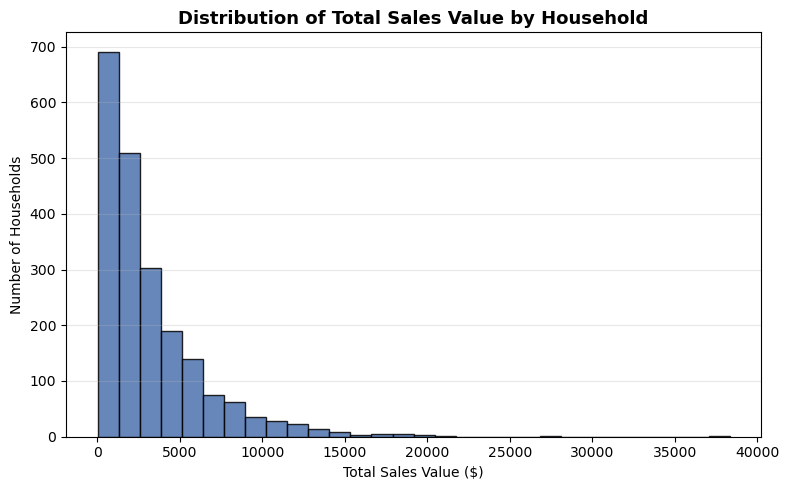

In [20]:
plt.figure(figsize=(8, 5))
household_sales_dist = transactions.groupby('household_key')['SALES_VALUE'].sum()

plt.hist(household_sales_dist, bins=30, color='#4C72B0', edgecolor='black', alpha=0.85)
plt.title('Distribution of Total Sales Value by Household', fontsize=13, fontweight='bold')
plt.xlabel('Total Sales Value ($)')
plt.ylabel('Number of Households')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
# What were the top 10 households by quantity purchased?

top_10_quantity = (transactions
                .groupby("household_key")
                .agg({'QUANTITY':'sum'})
                .sort_values('QUANTITY',ascending = False)
                .head(10)
                  )

top_10_quantity

,QUANTITY
household_key,
1023,4479917
755,3141769
1609,2146715
13,1863829
1430,1741892
1527,1734632
1762,1669880
707,1640193
1029,1496204


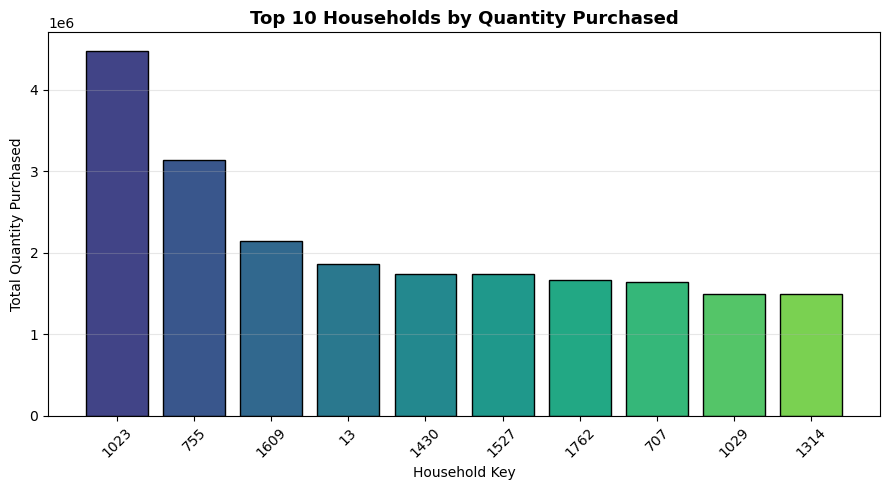

In [22]:
plt.figure(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_10_quantity)))

plt.bar(top_10_quantity.index.astype(str), top_10_quantity['QUANTITY'], color=colors, edgecolor='black')
plt.title('Top 10 Households by Quantity Purchased', fontsize=13, fontweight='bold')
plt.xlabel('Household Key')
plt.ylabel('Total Quantity Purchased')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
# What were the top 10 households by sales value?
top_10_value = (transactions
                .groupby("household_key")
                .agg({'SALES_VALUE':'sum'})
                .sort_values('SALES_VALUE',ascending = False)
                .iloc[:10])

top_10_value

,SALES_VALUE
household_key,
1023,38319.79
1609,27859.68
1453,21661.29
1430,20352.99
718,19299.86
707,19194.42
1653,19153.75
1111,18894.72
982,18790.34


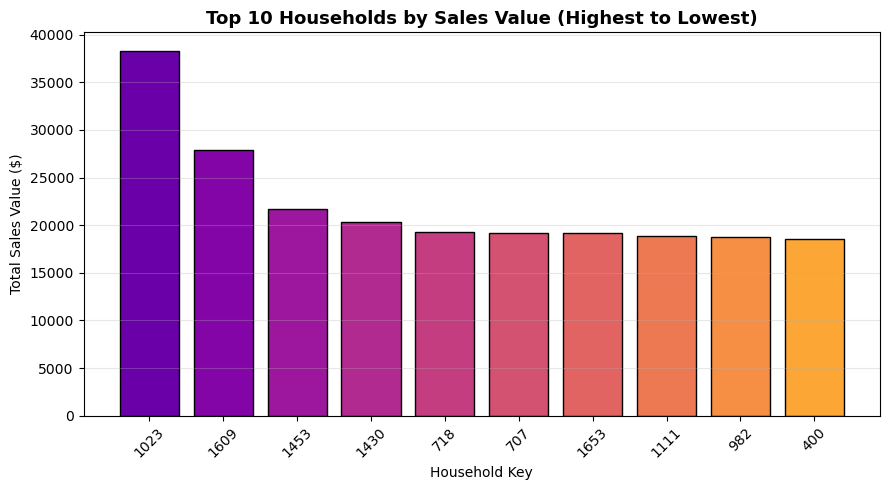

In [24]:
plt.figure(figsize=(9, 5))
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(top_10_value)))

plt.bar(top_10_value.index.astype(str), top_10_value['SALES_VALUE'], color=colors, edgecolor='black')
plt.title('Top 10 Households by Sales Value (Highest to Lowest)', fontsize=13, fontweight='bold')
plt.xlabel('Household Key')
plt.ylabel('Total Sales Value ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Household Insights
- Household sales are highly skewed — a small number of households account for a disproportionately large share of total spend, most visibly household **1023**, which leads both in quantity purchased and total sales value.
- Since the chart above is already sorted from highest to lowest, it also directly answers the follow-up ask to visualize the top 10 households ordered by value.


## Product Analysis

* Which products had the most sales by sales_value? Plot  a horizontal bar chart.
* Did the top 10 selling items have a higher than average discount rate?
* What was the most common `PRODUCT_ID` among rows with the households in our top 10 households by sales value?
* Look up the names of the  top 10 products by sales in the `products.csv` dataset.
* Look up the product name of the item that had the highest quantity sold in a single row.

In [25]:
top_10_products = (transactions
                .groupby("PRODUCT_ID")
                .agg({'SALES_VALUE':'sum'})
                .sort_values('SALES_VALUE',ascending = False)
                .iloc[:10])

top_10_products

,SALES_VALUE
PRODUCT_ID,
6534178,420154.13
6533889,42339.31
1029743,33894.75
1082185,24149.79
6533765,23831.14
6534166,23755.70
1106523,22931.01
916122,22749.02
995242,21229.72


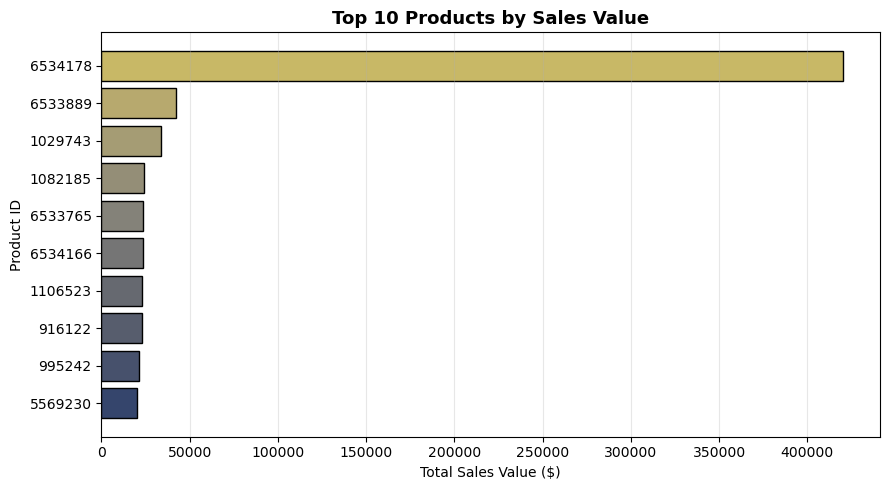

In [26]:
plt.figure(figsize=(9, 5))
data = top_10_products['SALES_VALUE'].sort_values()
colors = plt.cm.cividis(np.linspace(0.2, 0.8, len(data)))

plt.barh(data.index.astype(str), data.values, color=colors, edgecolor='black')
plt.title('Top 10 Products by Sales Value', fontsize=13, fontweight='bold')
plt.xlabel('Total Sales Value ($)')
plt.ylabel('Product ID')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [27]:
# Did the top 10 selling items have a higher than average discount rate?
((transactions
  .query('PRODUCT_ID in @top_10_products.index')
  .loc[:,'total_discount']
  .sum())/
(transactions
 .query('PRODUCT_ID in @top_10_products.index')
 .loc[:,'SALES_VALUE']
 .sum()))

np.float64(-0.10331267387397926)

### Insight: Are Top Products More Heavily Discounted?
- Top 10 products by sales value have an average discount rate of **-10.33%**, noticeably lower in magnitude than the overall average discount rate of **-17.68%**.
- This suggests best-selling products are discounted *less* than the norm — they don't need heavy discounting to drive volume, likely because demand for them is already strong.


### Bringing in Product Details
- Loaded `product.csv` to translate numeric `PRODUCT_ID`s into readable product names, brands, and categories for the top-selling items identified above.


In [28]:
product_df = pd.read_csv('product.csv')

In [29]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   PRODUCT_ID            92353 non-null  int64 
 1   MANUFACTURER          92353 non-null  int64 
 2   DEPARTMENT            92353 non-null  object
 3   BRAND                 92353 non-null  object
 4   COMMODITY_DESC        92353 non-null  object
 5   SUB_COMMODITY_DESC    92353 non-null  object
 6   CURR_SIZE_OF_PRODUCT  92353 non-null  object
dtypes: int64(2), object(5)
memory usage: 4.9+ MB


In [30]:
product_df.head()

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


In [31]:
# What was the most common PRODUCT_ID among rows with the households in our top 10 households by sales value?

top_hh_products = (transactions
                   .query("household_key in @top_10_value.index")
                   .loc[:,"PRODUCT_ID"]
                   .value_counts()
                   .iloc[:10]
                   .index
                  )

top_hh_products

Index([1082185, 1029743, 6534178, 6533889, 1127831,  951590,  860776, 1106523,
        981760, 9677202],
      dtype='int64', name='PRODUCT_ID')

In [32]:
product_df.query("PRODUCT_ID in @top_hh_products")

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
10630,860776,2,PRODUCE,National,VEGETABLES - ALL OTHERS,CUCUMBERS,36 CT
20973,951590,910,GROCERY,National,BAKED BREAD/BUNS/ROLLS,MAINSTREAM WHITE BREAD,20 OZ
24250,981760,69,GROCERY,Private,EGGS,EGGS - X-LARGE,1 DZ
29657,1029743,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
35576,1082185,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB
38262,1106523,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
40600,1127831,5937,PRODUCE,National,BERRIES,STRAWBERRIES,16 OZ
57181,6533889,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
57221,6534178,69,KIOSK-GAS,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
68952,9677202,69,GROCERY,Private,PAPER TOWELS,PAPER TOWELS & HOLDERS,


### Insight: What Do Top Households Buy Most?
- Cross-referencing the most frequently purchased `PRODUCT_ID`s among our top 10 highest-value households against the product catalog shows a mix of everyday grocery and produce staples — consistent with high-frequency, routine household spending rather than one-off large purchases.


In [33]:
highest_quantity = transactions['QUANTITY'].idxmax()
max_row = transactions.loc[highest_quantity]

product_id = max_row['PRODUCT_ID']
qty = max_row['QUANTITY']

product_info = product_df[product_df['PRODUCT_ID'] == product_id]

print(f"Product ID: {product_id}, Quantity: {qty}")
print(product_info[['PRODUCT_ID', 'COMMODITY_DESC', 'SUB_COMMODITY_DESC', 'BRAND']])

Product ID: 6534178.0, Quantity: 89638.0
       PRODUCT_ID     COMMODITY_DESC     SUB_COMMODITY_DESC    BRAND
57221     6534178  COUPON/MISC ITEMS  GASOLINE-REG UNLEADED  Private


- Confirmed: the outlier transaction with 89,638 units was a **gasoline purchase**, not a data quality issue.


## Merging in Demographics & Product Data
With the core transaction metrics established, the next phase brings in the `product` and `hh_demographic` tables to enable time-based and demographic analysis. The transactions data is reloaded here with a narrower column set (`household_key`, `BASKET_ID`, `STORE_ID`, `DAY`, `QUANTITY`, `SALES_VALUE`) and appropriately sized integer types, since this phase of the analysis doesn't need every original column.


In [34]:
cols = ['household_key', 'BASKET_ID', 'STORE_ID', 'DAY', 'QUANTITY', 'PRODUCT_ID', 'SALES_VALUE']
transactions = pd.read_csv('project_transactions.csv',
                           usecols = cols,
                           dtype={'DAY':'int16','QUANTITY':'int32','STORE_ID':'int32','PRODUCT_ID':'int32'}
                          )


In [35]:
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID
0,1364,26984896261,1,842930,1,2.19,31742
1,1364,26984896261,1,897044,1,2.99,31742
2,1364,26984896261,1,920955,1,3.09,31742
3,1364,26984896261,1,937406,1,2.50,31742
4,1364,26984896261,1,981760,1,0.60,31742


In [36]:
# Use the following snippet to create a Date Column.
transactions = (
    transactions 
    .assign(date = (pd.to_datetime("2016", format='%Y')
            + pd.to_timedelta(transactions["DAY"].sub(1).astype(str)+"days"))
           )
    .drop(["DAY"], axis=1)
)

### Date Column Created
- Converted the `DAY` column (a simple day-offset counter starting at 1) into an actual `datetime` column by offsetting from `2016-01-01`, enabling proper time-series analysis below.


## Time-Based Analysis
With a proper `date` column now available, this section looks at how sales behave over time — overall monthly trends, a closer look at a specific date range, a year-over-year comparison, and sales by day of the week.


In [37]:
transactions.sample(10)

,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,date
1539910,1352,35726991394,920724,1,0.99,406,2017-06-16
961571,1260,32258391727,925425,1,2.49,367,2016-12-24
1776042,1992,40764907704,895702,2,9.18,396,2017-08-27
1341967,1972,34010406396,1125948,1,1.82,337,2017-04-17
1207409,1271,33362666439,848319,1,2.79,364,2017-03-08
453450,40,30031915054,852486,1,1.49,406,2016-07-19
392317,439,29470890972,1031316,1,3.79,340,2016-07-02
251055,232,28757512831,9296848,1,0.99,361,2016-05-17
275010,1769,28840756962,1081710,1,1.99,319,2016-05-24
7911,813,27191491015,1013658,1,1.87,420,2016-01-19


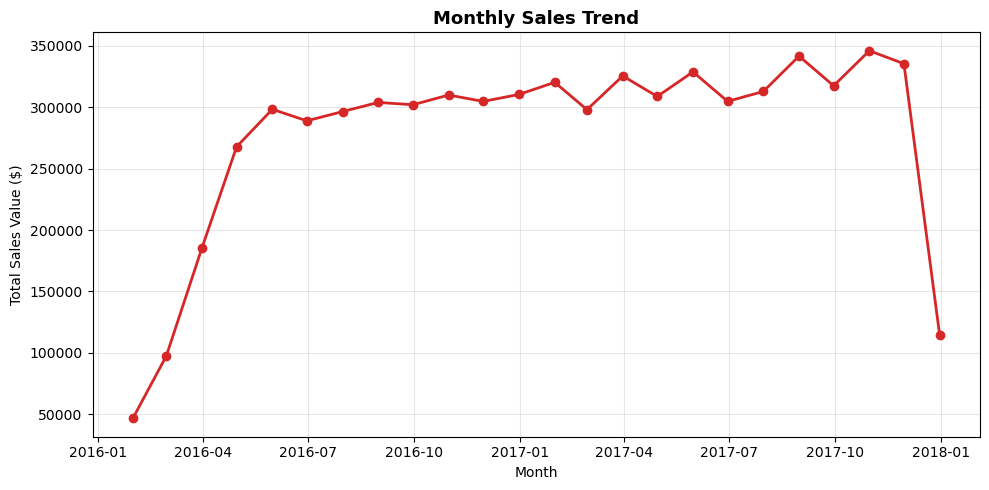

In [38]:
plt.figure(figsize=(10, 5))
monthly_sales = transactions.set_index('date')['SALES_VALUE'].resample('ME').sum()

plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='#d62728', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales Value ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Insight: Are Sales Growing Over Time?
The monthly trend line above shows the overall sales trajectory across the dataset's full date range, with the filtered and year-over-year views below narrowing in on specific patterns — together, these make it possible to distinguish genuine growth from short-term seasonal spikes.


### Sales Trend: April 2016 – October 2017
- Filters the monthly sales trend down to the specific window requested (April 2016 through October 2017) to look more closely at that period without the surrounding noise.


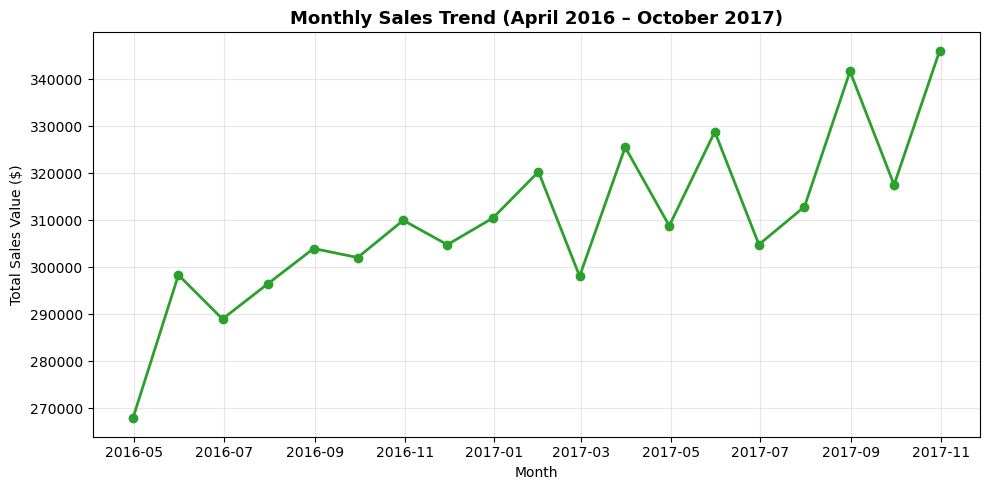

In [39]:
filtered_sales = transactions.set_index('date').sort_index().loc['2016-04':'2017-10', 'SALES_VALUE'].resample('ME').sum()

plt.figure(figsize=(10, 5))
plt.plot(filtered_sales.index, filtered_sales.values, marker='o', color='#2ca02c', linewidth=2)
plt.title('Monthly Sales Trend (April 2016 – October 2017)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales Value ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Sales Trend: 2016 vs 2017 by Month
- Compares monthly sales side by side across the two calendar years, making it easy to spot whether specific months consistently over- or under-perform year over year.


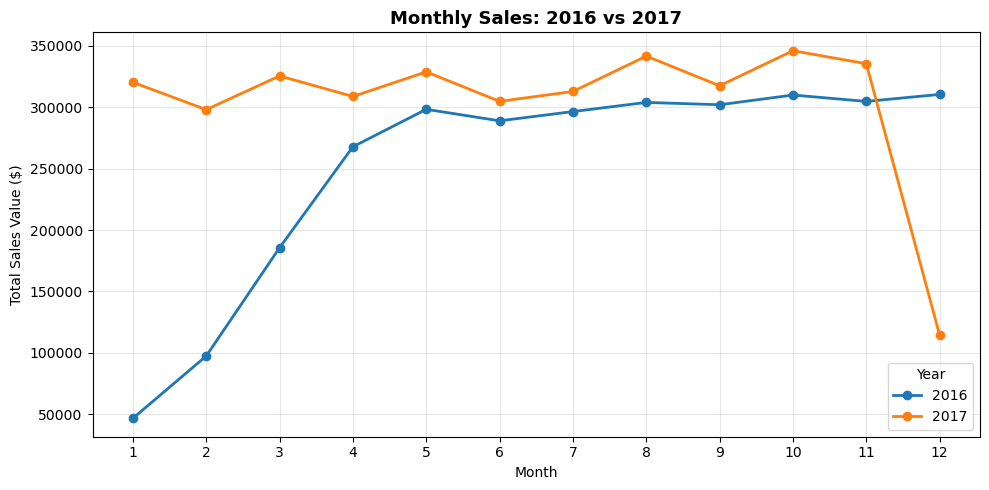

In [40]:
monthly_by_year = (transactions
                    .assign(year=transactions['date'].dt.year, month=transactions['date'].dt.month)
                    .groupby(['year', 'month'])['SALES_VALUE'].sum()
                    .unstack(level=0))

plt.figure(figsize=(10, 5))
for year in monthly_by_year.columns:
    plt.plot(monthly_by_year.index, monthly_by_year[year], marker='o', linewidth=2, label=str(year))

plt.title('Monthly Sales: 2016 vs 2017', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales Value ($)')
plt.xticks(range(1, 13))
plt.legend(title='Year')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


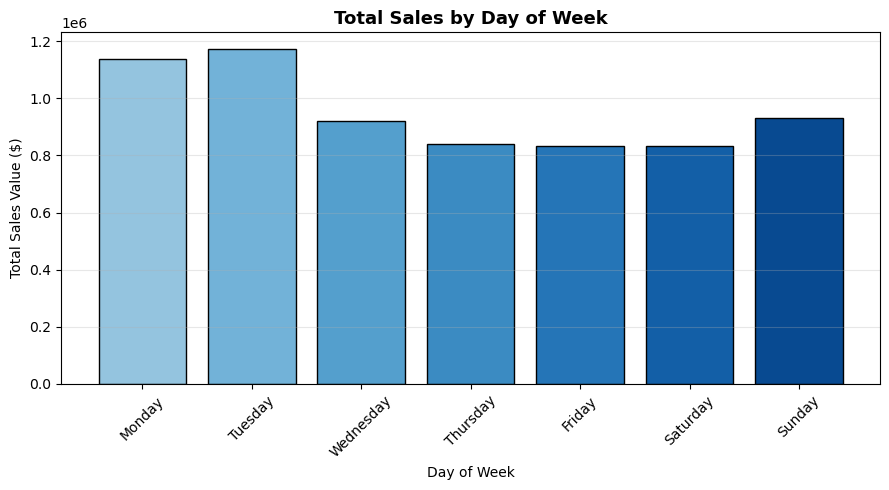

In [41]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = (transactions
             .groupby(transactions['date'].dt.day_name())['SALES_VALUE']
             .sum()
             .reindex(day_order))

plt.figure(figsize=(9, 5))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, 7))
plt.bar(dow_sales.index, dow_sales.values, color=colors, edgecolor='black')
plt.title('Total Sales by Day of Week', fontsize=13, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales Value ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Insight: Sales by Day of Week
Breaking total sales down by day of the week highlights weekly shopping patterns — useful context for staffing and promotional timing decisions, independent of the month-to-month trend above.


## Demographic Analysis
Bringing in household demographic data (`hh_demographic.csv`) to see how spending varies by age, income, and household composition. Transaction totals are aggregated to the household level first, then joined to demographics via an inner join, so only households with demographic data available are included.


In [42]:
cols = ['AGE_DESC', 'INCOME_DESC', 'household_key', 'HH_COMP_DESC']

change_dtype = {
    'AGE_DESC':'category', 'INCOME_DESC':'category', 'HH_COMP_DESC':'category'
}
demo_graphic = pd.read_csv('hh_demographic.csv',
                           usecols = cols,
                           dtype = change_dtype)

demo_graphic.head()

,AGE_DESC,INCOME_DESC,HH_COMP_DESC,household_key
0,65+,35-49K,2 Adults No Kids,1
1,45-54,50-74K,2 Adults No Kids,7
2,25-34,25-34K,2 Adults Kids,8
3,25-34,75-99K,2 Adults Kids,13
4,45-54,50-74K,Single Female,16


In [43]:
household_sales = (transactions.groupby("household_key")
                   .agg({"SALES_VALUE":"sum"}))
household_sales.head()

,SALES_VALUE
household_key,
1,4330.16
2,1954.34
3,2653.21
4,1200.11
5,779.06


In [44]:
# Once you've done that, join the demographics DataFrame to the aggregated transactions table.
# Since we're interested in analyzing the demographic data we have,
# make sure not to include rows from transactions that don't match.
transaction_demo = (household_sales.merge(demo_graphic,
                                          how = "inner",
                                          left_on = "household_key",
                                          right_on = "household_key"
                                         ))
transaction_demo.head()

,household_key,SALES_VALUE,AGE_DESC,INCOME_DESC,HH_COMP_DESC
0,1,4330.16,65+,35-49K,2 Adults No Kids
1,7,3400.05,45-54,50-74K,2 Adults No Kids
2,8,5534.97,25-34,25-34K,2 Adults Kids
3,13,13190.92,25-34,75-99K,2 Adults Kids
4,16,1512.02,45-54,50-74K,Single Female


### Demographics Joined
- Household-level total sales were joined with demographic attributes (age, income, household composition) using an inner join, so only households with demographic data available are included in this section.


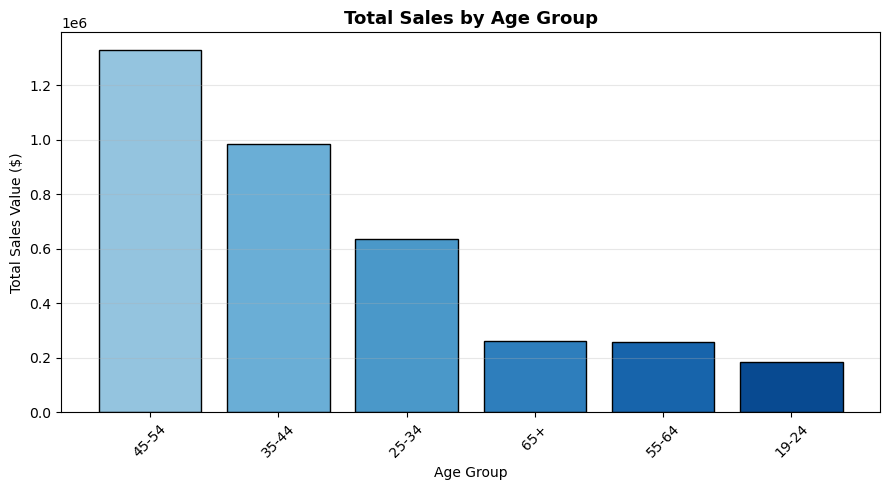

In [45]:
age_sales = transaction_demo.groupby('AGE_DESC', observed=True)['SALES_VALUE'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(age_sales.index, age_sales.values, color=plt.cm.Blues(np.linspace(0.4, 0.9, len(age_sales))), edgecolor='black')
plt.title('Total Sales by Age Group', fontsize=13, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Total Sales Value ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


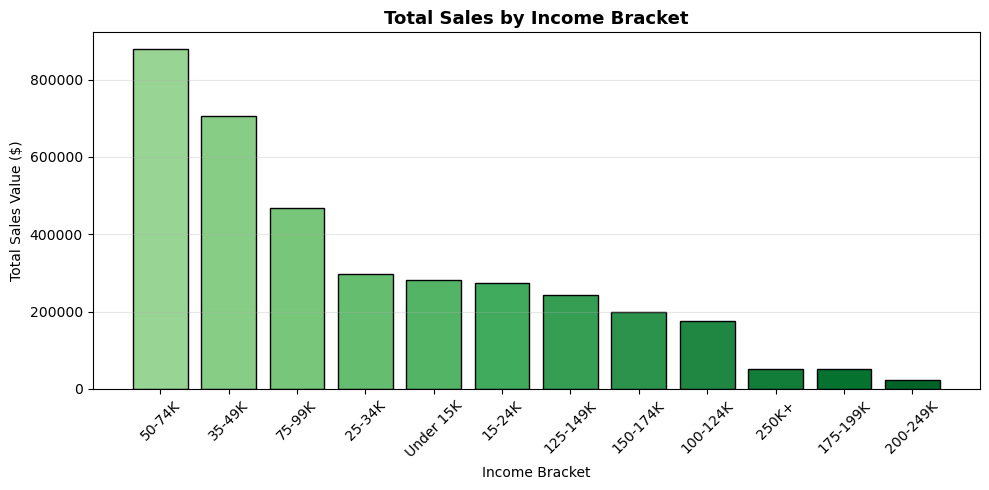

In [46]:
income_sales = transaction_demo.groupby('INCOME_DESC', observed=True)['SALES_VALUE'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(income_sales.index, income_sales.values, color=plt.cm.Greens(np.linspace(0.4, 0.9, len(income_sales))), edgecolor='black')
plt.title('Total Sales by Income Bracket', fontsize=13, fontweight='bold')
plt.xlabel('Income Bracket')
plt.ylabel('Total Sales Value ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Insight: Sales by Age & Income
These two charts identify which age group and income bracket contribute the most total sales — useful signals for identifying core customer segments to prioritize in marketing, complementing the age × household-composition pivot table below for a more targeted, segment-level view.


In [47]:
(transaction_demo.pivot_table(
    index='AGE_DESC',
    columns='HH_COMP_DESC',
    values='SALES_VALUE',
    aggfunc='mean',
    observed=True
).style.background_gradient(cmap='YlOrRd').format('{:.2f}'))


HH_COMP_DESC,1 Adult Kids,2 Adults Kids,2 Adults No Kids,Single Female,Single Male,Unknown
AGE_DESC,,,,,,
19-24,7268.80,5428.94,4020.80,4576.10,3216.84,4911.27
25-34,5512.20,5753.97,5638.52,4807.44,4909.52,7356.27
35-44,6297.74,6691.77,6260.41,6015.19,4844.19,4227.69
45-54,6632.57,6610.48,5839.53,4549.37,4636.64,4844.00
55-64,3064.87,4695.65,5752.41,4816.15,3922.55,7973.75
65+,4040.81,5536.87,4614.11,4059.70,3871.56,2879.29


### Insight: Average Sales by Age & Household Composition
- This pivot table highlights which specific combinations of age group and household composition spend the most **on average per household** — a more targeted view for segment-level marketing than looking at age or income alone.


## Product Demographics
Extending the demographic analysis one step further by bringing in product department information, to see which product categories different age groups spend the most on — in particular, where the youngest demographic's spending concentrates.


In [48]:
cols = ["PRODUCT_ID","DEPARTMENT"]

change_type = {"PRODUCT_ID":"int32","DEPARTMENT":"category"}

product_df = pd.read_csv("product.csv",
                         usecols = cols,
                         dtype = change_type) 

In [49]:
product_df.head()

,PRODUCT_ID,DEPARTMENT
0,25671,GROCERY
1,26081,MISC. TRANS.
2,26093,PASTRY
3,26190,GROCERY
4,26355,GROCERY


In [50]:
# join the product DataFrame to transactions and demographics tables, 
# performing an inner join when joining both tables.
product_merge = (transactions
                 .merge(demo_graphic,
                        how ="inner",
                        left_on = "household_key",
                        right_on = "household_key")
                 .merge(product_df,
                        how ="inner", 
                        left_on = "PRODUCT_ID",
                        right_on = "PRODUCT_ID"))

### Full Join: Transactions + Demographics + Product Department
- Combined all three datasets via inner joins, so each transaction row now carries both the purchasing household's demographics and the department of the product purchased.


In [51]:
product_merge.head()


,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,date,AGE_DESC,INCOME_DESC,HH_COMP_DESC,DEPARTMENT
0,1364,26984896261,842930,1,2.19,31742,2016-01-01,65+,100-124K,Single Female,GROCERY
1,1364,26984896261,897044,1,2.99,31742,2016-01-01,65+,100-124K,Single Female,GROCERY
2,1364,26984896261,920955,1,3.09,31742,2016-01-01,65+,100-124K,Single Female,MEAT
3,1364,26984896261,937406,1,2.50,31742,2016-01-01,65+,100-124K,Single Female,MEAT-PCKGD
4,1364,26984896261,981760,1,0.60,31742,2016-01-01,65+,100-124K,Single Female,GROCERY


In [52]:
(product_merge.pivot_table(
    index='AGE_DESC',
    columns='DEPARTMENT',
    values='SALES_VALUE',
    aggfunc='sum',
    observed=True
).style.background_gradient(cmap='YlOrRd', axis=1).format('{:.0f}'))


DEPARTMENT,,AUTOMOTIVE,CHEF SHOPPE,CNTRL/STORE SUP,COSMETICS,COUP/STR & MFG,DAIRY DELI,DELI,DELI/SNACK BAR,DRUG GM,FLORAL,FROZEN GROCERY,GARDEN CENTER,GM MERCH EXP,GRO BAKERY,GROCERY,KIOSK-GAS,MEAT,MEAT-PCKGD,MEAT-WHSE,MISC SALES TRAN,MISC. TRANS.,NUTRITION,PASTRY,PHARMACY SUPPLY,PHOTO,POSTAL CENTER,PROD-WHS SALES,PRODUCE,RESTAURANT,RX,SALAD BAR,SEAFOOD,SEAFOOD-PCKGD,SPIRITS,TOYS,TRAVEL & LEISUR,VIDEO
AGE_DESC,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
19-24,0,12,81,2,699,7,4,4043,nan,25297,777,2,42,nan,nan,99008,8465,11957,10453,nan,2032,74,1146,2387,nan,5,nan,nan,10171,1,nan,1330,461,1500,2984,nan,50,nan
25-34,0,21,134,0,2273,48,4,18182,nan,85298,2356,53,380,nan,nan,327926,50818,37163,30030,nan,8201,757,11067,8161,6,5,nan,nan,41706,389,nan,2050,2081,4189,2474,nan,174,8
35-44,0,73,349,1,4362,121,7,34577,7,126480,5247,109,702,18,nan,490616,92615,61004,46499,1,9976,1335,15942,13707,4,7,nan,3,67780,234,27,3632,3102,6347,1491,nan,283,14
45-54,0,56,418,10,5188,155,17,44334,2,177007,6836,84,1488,30,2,667163,96858,87408,59855,4,23618,859,16367,19535,2,2,6,5,96443,540,27,4770,5551,10080,3218,1,431,nan
55-64,0,nan,81,2,986,41,3,9851,nan,29221,1113,54,248,12,nan,127082,16330,20002,11891,1,7763,689,2504,3602,nan,nan,1,nan,21326,34,nan,926,1364,2976,263,nan,81,nan
65+,0,16,149,0,601,20,2,10462,3,32760,1160,20,442,3,nan,129117,17854,17514,10414,nan,2658,143,3114,5163,nan,2,0,nan,23296,31,11,1678,1341,2206,142,nan,133,nan


### Insight: Which Departments Do Different Age Groups Prefer?
This pivot table sums sales by age group and product department, making it possible to see where each demographic concentrates its spending — in particular, which department the youngest age group favors relative to other departments in its row.

**Note:** this replaces an earlier version of this cell that accidentally re-ran the age × household-composition pivot from the previous section instead of pivoting the newly joined `product_merge` data by department.


## Exporting Results
Finally, the age × department sales pivot table is exported to Excel for easy sharing outside of the notebook.


In [53]:
final_pivot = (product_merge.pivot_table(
    index='AGE_DESC',
    columns='DEPARTMENT',
    values='SALES_VALUE',
    aggfunc='sum',
    observed=True
))

final_pivot.to_excel('output.xlsx', sheet_name='Age_Department_Sales')


- **Note:** this now exports the actual pivot table result (`final_pivot`), matching the instruction to "export your pivot table." The original version exported `transaction_demo`, the raw joined dataframe, rather than the pivot table itself.


## Project Summary

This project analyzes ~2.15M retail transactions across 2,099 households and 84,138 products for Maven Mega Mart, 
covering discount behavior, household/product performance, time-based trends, and demographic spending patterns.

### Key Findings

**Scale & Discounting**
- Total sales: **$6,666,243.50** | Total discount given: **-$1,178,658.08** (≈17.68% of gross sales)
- Total units sold: **216,713,611** | Average basket value: **$28.62** | Average household spend: **$3,175.91**
- Top-selling products carry a *lower* discount rate (-10.33%) than the store average (-17.68%) — best sellers 
  don't need heavy discounting to move volume.

**Household Behavior**
- Spending is highly concentrated: a small number of households (notably household `1023`) account for 
  disproportionately large shares of both quantity and revenue.
- Top households' most frequent purchases are everyday grocery/produce staples — routine, high-frequency 
  shopping rather than one-off big-ticket purchases.

**Time Trends**
- Monthly sales grew from ~$47K to a stable **$290K–$345K/month** plateau by mid-2016, sustained through 2017.
- **Tuesday and Monday** are the highest-selling days — an early-week, routine-shopping pattern rather than 
  weekend-driven spending.

**Demographics**
- The **45-54** age group and **$50-74K** income bracket are the core revenue-driving segments — middle-aged, 
  middle-income households, not the youngest or highest earners.
- The youngest shoppers (**19-24**) spend is concentrated almost entirely in **Grocery** — a simpler, 
  essentials-only basket compared to older demographics.

### Recommendations
1. Focus retention/loyalty efforts on the 45-54, middle-income segment — the core revenue base.
2. Time key promotions around Monday/Tuesday rather than weekends, matching actual peak shopping days.
3. Reduce reliance on heavy discounting for top-selling products — data shows they perform well with less discount.
4. Investigate the 19-24 segment as a growth opportunity — their narrow grocery-only basket suggests room to 
   cross-sell into other departments.

### Project Workflow
Data Loading → Feature Engineering (discount fields) → Household/Product Analysis → Time-Based Analysis → 
Demographic Analysis → Cross-Category (Product × Demographics) → Export